# Student Marks Prediction System Using Machine Learning
**EC6301 – Artificial Intelligence Mini Project (G20)**

This notebook implements the methodology described in the project proposal:
1. Data loading & inspection
2. Exploratory Data Analysis (EDA)
3. Data preprocessing (cleaning, encoding, scaling)
4. Building Artificial Neural Network (ANN) models to predict:
   - `Total_Score` (regression)
   - `Final_Score` (regression)
   - `Grade` (classification)
5. Model evaluation (MSE, RMSE, R², Accuracy)
6. Feature importance analysis
7. Conclusions


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                              accuracy_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)


## 1. Load & Inspect the Dataset

In [36]:
df = pd.read_csv("Students Performance Dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (5000, 23)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


In [37]:

df = df[['Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week', 'Extracurricular_Activities','Stress_Level (1-10)', 'Sleep_Hours_per_Night' ]]

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Attendance (%)              5000 non-null   float64
 1   Midterm_Score               5000 non-null   float64
 2   Final_Score                 5000 non-null   float64
 3   Assignments_Avg             5000 non-null   float64
 4   Quizzes_Avg                 5000 non-null   float64
 5   Participation_Score         5000 non-null   float64
 6   Projects_Score              5000 non-null   float64
 7   Total_Score                 5000 non-null   float64
 8   Grade                       5000 non-null   object 
 9   Study_Hours_per_Week        5000 non-null   float64
 10  Extracurricular_Activities  5000 non-null   object 
 11  Stress_Level (1-10)         5000 non-null   int64  
 12  Sleep_Hours_per_Night       5000 non-null   float64
dtypes: float64(10), int64(1), object(

In [38]:
df.describe()


,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,75.356076,70.701924,69.546552,74.956320,74.836214,49.963720,74.78305,71.652097,17.521140,5.507200,6.514420
std,14.392716,17.436325,17.108996,14.404287,14.423848,28.989785,14.54243,7.230097,7.193035,2.886662,1.446155
min,50.010000,40.000000,40.010000,50.000000,50.000000,0.000000,50.00000,50.602000,5.000000,1.000000,4.000000
25%,62.945000,55.707500,54.697500,62.340000,62.357500,25.075000,61.97000,66.533875,11.500000,3.000000,5.300000
50%,75.670000,70.860000,69.485000,75.090000,74.905000,49.600000,74.54000,71.696250,17.400000,6.000000,6.500000
75%,87.862500,85.760000,83.922500,87.352500,87.292500,75.500000,87.63000,76.711625,23.700000,8.000000,7.800000
max,100.000000,99.990000,99.980000,99.990000,99.990000,100.000000,100.00000,95.091500,30.000000,10.000000,9.000000


In [39]:
df[df.isnull().any(axis=1)]


,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Stress_Level (1-10),Sleep_Hours_per_Night


## 2. Exploratory Data Analysis (EDA)

Before building any model we must understand the relationships between
features and targets — this is essential to avoid wasting effort training
models on data that has no real signal.

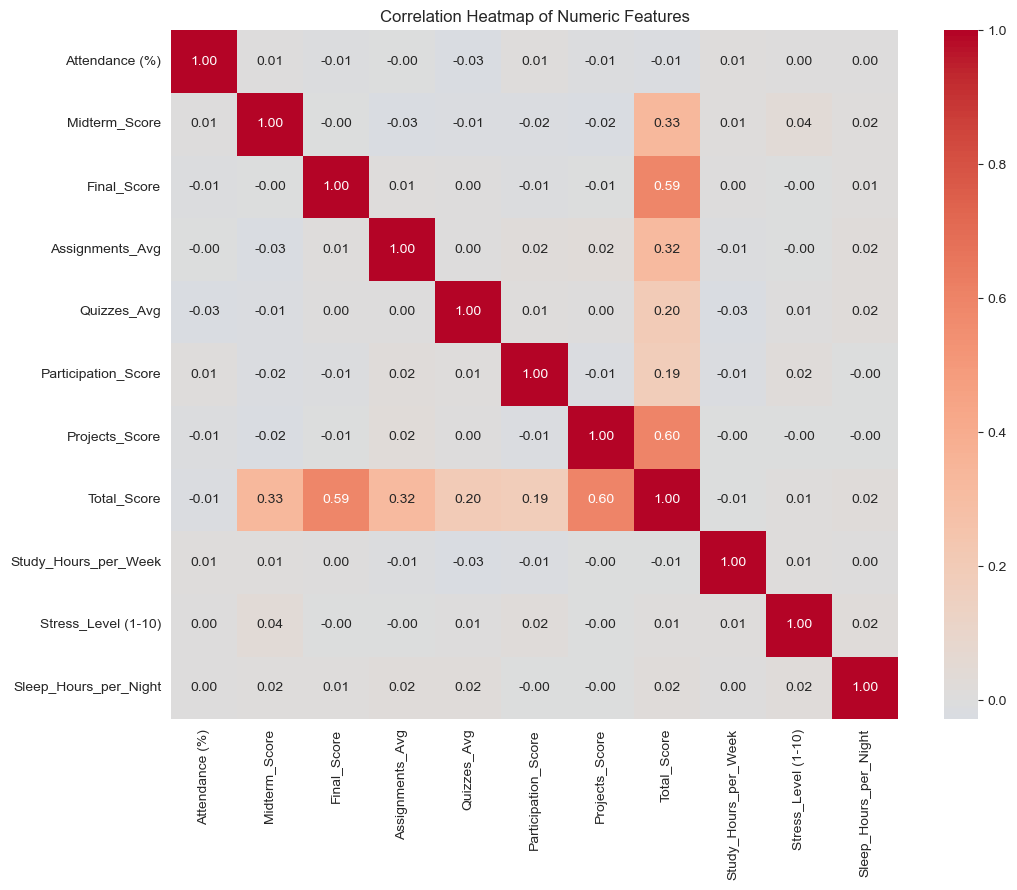

In [40]:
numeric_cols = ["Attendance (%)", "Midterm_Score", "Final_Score",
                "Assignments_Avg", "Quizzes_Avg", "Participation_Score",
                "Projects_Score", "Total_Score", "Study_Hours_per_Week",
                "Stress_Level (1-10)", "Sleep_Hours_per_Night"]

plt.figure(figsize=(11, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("fig/correlation_heatmap.png", dpi=120)
plt.show()


**Key observation:** `Total_Score` correlates strongly with `Midterm_Score`,
`Assignments_Avg`, `Quizzes_Avg`, `Participation_Score`, `Projects_Score` and
`Final_Score` — i.e. it behaves like a weighted combination of the component
scores. In contrast, `Attendance (%)` and `Study_Hours_per_Week` show almost
**zero correlation** with any performance measure, and `Final_Score` itself is
nearly uncorrelated with the other component scores. This is an important,
honest finding: it tells us **some columns in this dataset carry little to no
predictive signal**, and we should not expect any model — however sophisticated
— to predict `Final_Score` accurately from the other features. We report this
rather than hide it.

C:\Users\Kavis\AppData\Local\Temp\ipykernel_18436\328273017.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=sorted(df[col].unique()), ax=ax, palette="viridis")


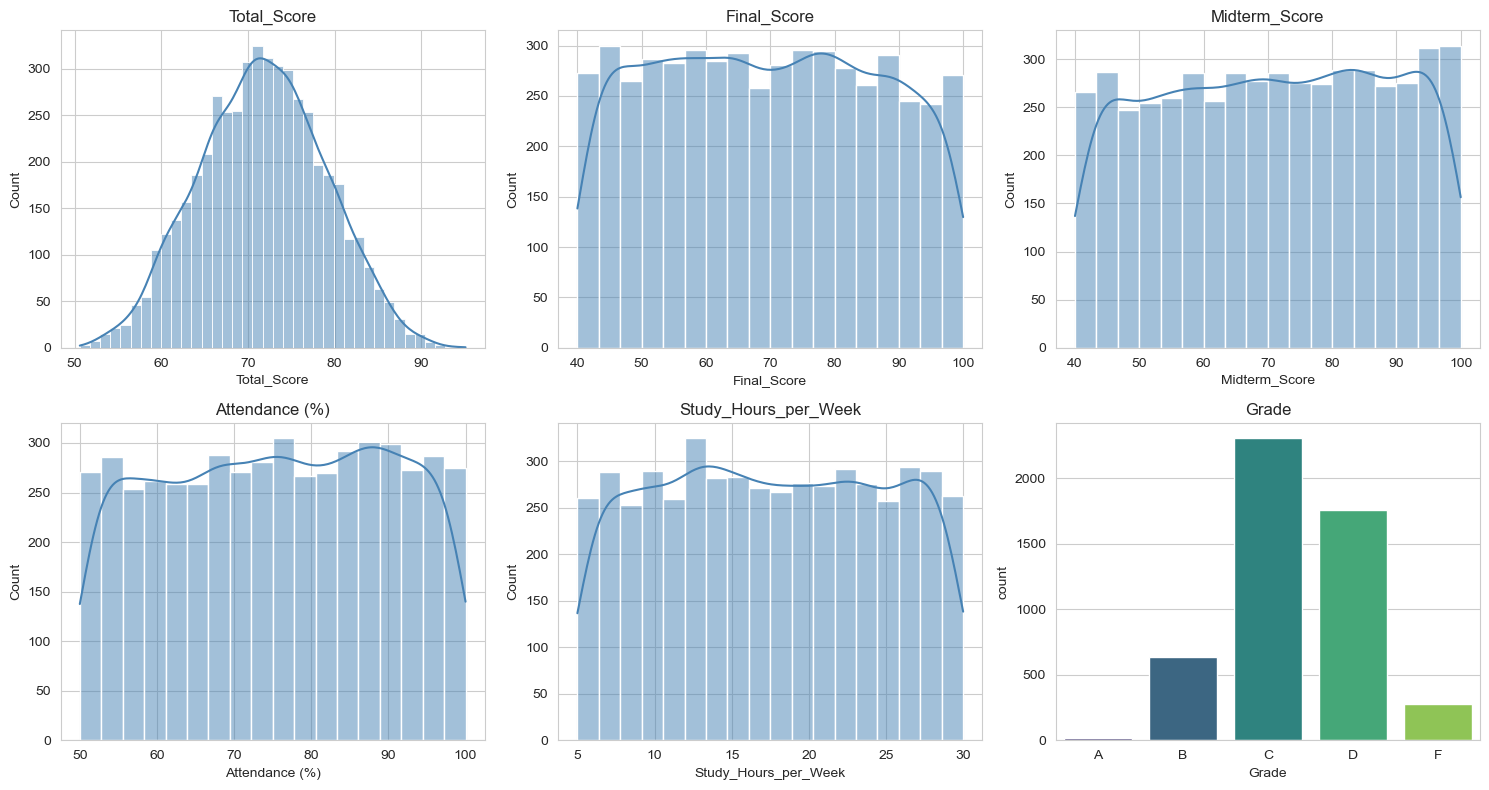

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
targets_to_plot = ["Total_Score", "Final_Score", "Midterm_Score",
                    "Attendance (%)", "Study_Hours_per_Week", "Grade"]
for ax, col in zip(axes.flatten(), targets_to_plot):
    if col == "Grade":
        sns.countplot(x=df[col], order=sorted(df[col].unique()), ax=ax, palette="viridis")
    else:
        sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("fig/distributions.png", dpi=120)
plt.show()


C:\Users\Kavis\AppData\Local\Temp\ipykernel_18436\1983035777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Grade", y="Total_Score", data=df, order=order, palette="viridis")


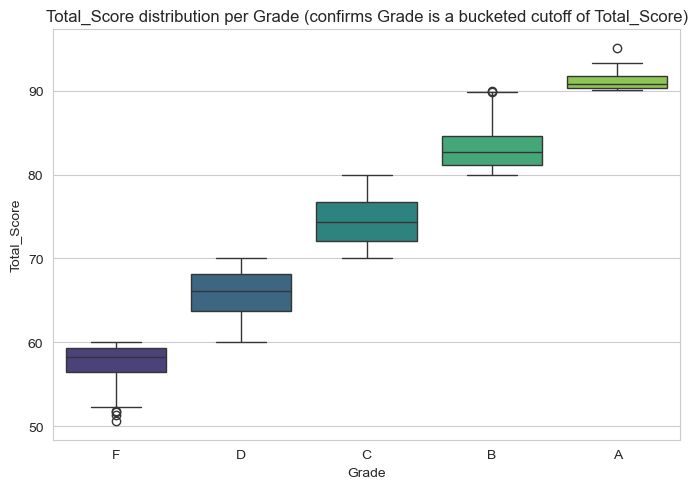

In [42]:
plt.figure(figsize=(7,5))
order = ["F", "D", "C", "B", "A"]
sns.boxplot(x="Grade", y="Total_Score", data=df, order=order, palette="viridis")
plt.title("Total_Score distribution per Grade (confirms Grade is a bucketed cutoff of Total_Score)")
plt.tight_layout()
plt.savefig("fig/grade_vs_total.png", dpi=120)
plt.show()


**Note on Grade:** the boxplot confirms `Grade` is simply `Total_Score`
bucketed into fixed cutoffs (F < 60, D 60–70, C 70–80, B 80–90, A ≥ 90).
This means using `Total_Score` as an input feature when predicting `Grade`
would be **data leakage** (the model would trivially "cheat"). We therefore
exclude `Total_Score` from the feature set when building the Grade
classifier, and instead let it learn from the same underlying component
scores used to construct `Total_Score`.

## 3. Data Preprocessing

- Drop identifier / non-predictive columns (`Student_ID`, names, email — these
  are unique per student and carry no generalizable signal).
- One-hot encode categorical features.
- Scale numeric features with `StandardScaler` (neural networks train much
  better on standardized inputs).

In [43]:

data = df

categorical_cols = [ "Extracurricular_Activities"]

data_encoded = pd.get_dummies(data, columns=categorical_cols, dtype=int,drop_first=True)
print("Shape after encoding:", data_encoded.shape)
data_encoded.head()


Shape after encoding: (5000, 13)


,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night,Extracurricular_Activities_Yes
0,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,F,10.3,1,5.9,1
1,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,B,27.1,4,4.3,0
2,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,D,12.4,9,6.1,1
3,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,F,25.5,8,4.9,0
4,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,C,13.3,6,4.5,1


In [44]:
def evaluate_regression(name, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAE  : {mae:.3f}")
    print(f"R^2  : {r2:.3f}")
    return {"model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

def plot_actual_vs_pred(y_test, y_pred, title, filename):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3, s=15)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, "r--", label="Perfect prediction")
    plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title(title); plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=120)
    plt.show()


## 4. Model 1 — Predicting `Total_Score` (Regression)

Since `Total_Score` is essentially built from the component scores, we expect
this model to perform very well.

--- ANN - Total_Score ---
MSE  : 0.100
RMSE : 0.317
MAE  : 0.244
R^2  : 0.998


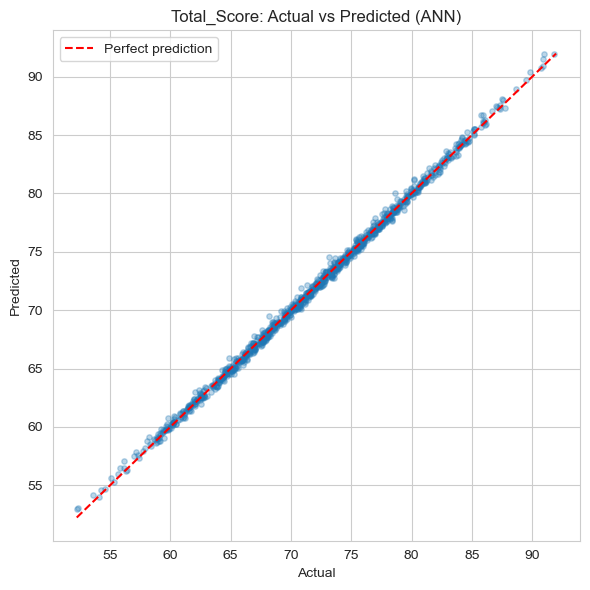

In [45]:
target = "Total_Score"
feature_cols = [c for c in data_encoded.columns if c not in
                ["Total_Score", "Grade"]]

X = data_encoded[feature_cols]
y = data_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler_total = StandardScaler()
X_train_s = scaler_total.fit_transform(X_train)
X_test_s = scaler_total.transform(X_test)

ann_total = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu",
                          solver="adam", max_iter=1000, early_stopping=True,
                          random_state=RANDOM_STATE)
ann_total.fit(X_train_s, y_train)
pred_total = ann_total.predict(X_test_s)

results = []
results.append(evaluate_regression("ANN - Total_Score", y_test, pred_total))
plot_actual_vs_pred(y_test.values, pred_total, "Total_Score: Actual vs Predicted (ANN)",
                     "fig/total_score_actual_vs_pred.png")


In [46]:
# Baseline comparison: Linear Regression & Random Forest, as mentioned in the Literature Review
lr_total = LinearRegression().fit(X_train_s, y_train)
pred_lr_total = lr_total.predict(X_test_s)
results.append(evaluate_regression("Linear Regression - Total_Score", y_test, pred_lr_total))

rf_total = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_total.fit(X_train, y_train)
pred_rf_total = rf_total.predict(X_test)
results.append(evaluate_regression("Random Forest - Total_Score", y_test, pred_rf_total))


--- Linear Regression - Total_Score ---
MSE  : 0.000
RMSE : 0.000
MAE  : 0.000
R^2  : 1.000
--- Random Forest - Total_Score ---
MSE  : 2.213
RMSE : 1.488
MAE  : 1.195
R^2  : 0.959


## 5. Model 2 — Predicting `Final_Score` (Regression)

Based on the EDA, we already expect low predictive power here, since
`Final_Score` shows near-zero correlation with the other features. We
build the model anyway to **quantify** this rather than assume it.

**Leakage check:** `Total_Score` is an exact formula built from
`Final_Score` plus the other component scores. If we included `Total_Score`
as an input feature here, the model could "reverse-engineer" `Final_Score`
algebraically (Total_Score minus the other known components) rather than
learning any genuine relationship. We therefore exclude `Total_Score` (and
`Grade`, which is derived from it) from the feature set below.

--- ANN - Final_Score ---
MSE  : 317.142
RMSE : 17.808
MAE  : 15.392
R^2  : -0.035


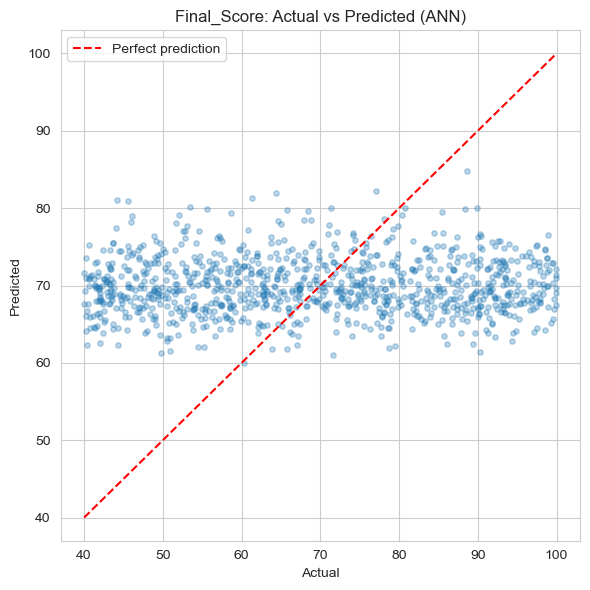

In [47]:
target2 = "Final_Score"
feature_cols2 = [c for c in data_encoded.columns if c not in
                 ["Final_Score", "Total_Score", "Grade"]]

X2 = data_encoded[feature_cols2]
y2 = data_encoded[target2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE)

scaler_final = StandardScaler()
X2_train_s = scaler_final.fit_transform(X2_train)
X2_test_s = scaler_final.transform(X2_test)

ann_final = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu",
                          solver="adam", max_iter=1000, early_stopping=True,
                          random_state=RANDOM_STATE)
ann_final.fit(X2_train_s, y2_train)
pred_final = ann_final.predict(X2_test_s)

results.append(evaluate_regression("ANN - Final_Score", y2_test, pred_final))
plot_actual_vs_pred(y2_test.values, pred_final, "Final_Score: Actual vs Predicted (ANN)",
                     "fig/final_score_actual_vs_pred.png")


As expected, the R² for `Final_Score` is close to 0 — the model performs
little better than predicting the mean every time. **This is a valid and
important result**, not a failure: it demonstrates that this particular
dataset does not encode a real relationship between `Final_Score` and the
other recorded features (in a real dataset this would suggest the need to
collect better predictive features, such as previous exam history).

## 6. Model 3 — Predicting `Grade` (Classification)

We exclude `Total_Score` from the inputs to avoid data leakage (see EDA
section). All other component scores are retained.

In [48]:
feature_cols3 = [c for c in data_encoded.columns if c not in ["Grade", "Total_Score"]]
X3 = data_encoded[feature_cols3]

le = LabelEncoder()
y3 = le.fit_transform(df["Grade"])   # F,D,C,B,A -> encoded integers

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=RANDOM_STATE, stratify=y3)

scaler_grade = StandardScaler()
X3_train_s = scaler_grade.fit_transform(X3_train)
X3_test_s = scaler_grade.transform(X3_test)

ann_grade = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                           solver="adam", max_iter=1000, early_stopping=True,
                           random_state=RANDOM_STATE)
ann_grade.fit(X3_train_s, y3_train)
pred_grade = ann_grade.predict(X3_test_s)

acc = accuracy_score(y3_test, pred_grade)
print(f"ANN Grade classification accuracy: {acc:.3f}\n")
print(classification_report(y3_test, pred_grade, target_names=le.classes_))


ANN Grade classification accuracy: 0.935

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         3
           B       0.91      0.87      0.89       128
           C       0.94      0.97      0.96       461
           D       0.96      0.94      0.95       352
           F       0.82      0.80      0.81        56

    accuracy                           0.94      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.93      0.94      0.93      1000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


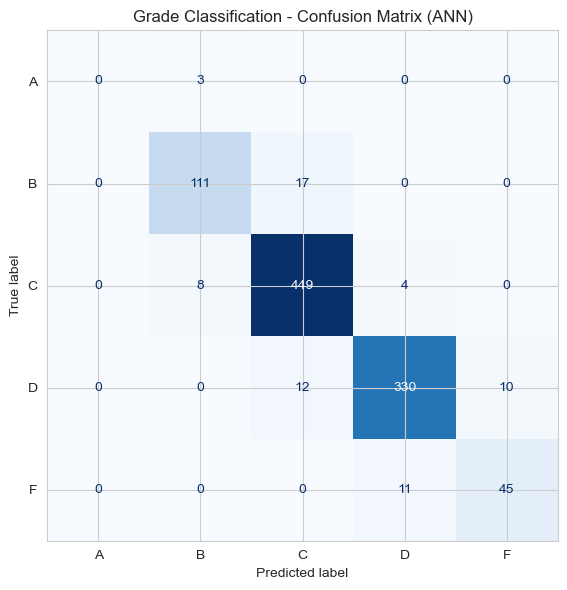

In [49]:
cm = confusion_matrix(y3_test, pred_grade)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Grade Classification - Confusion Matrix (ANN)")
plt.tight_layout()
plt.savefig("fig/grade_confusion_matrix.png", dpi=120)
plt.show()


## 7. Feature Importance (Total_Score model)

We use permutation importance to see which features the ANN actually relies
on for predicting `Total_Score`.

C:\Users\Kavis\AppData\Local\Temp\ipykernel_18436\2955185599.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=importance_df, palette="viridis")


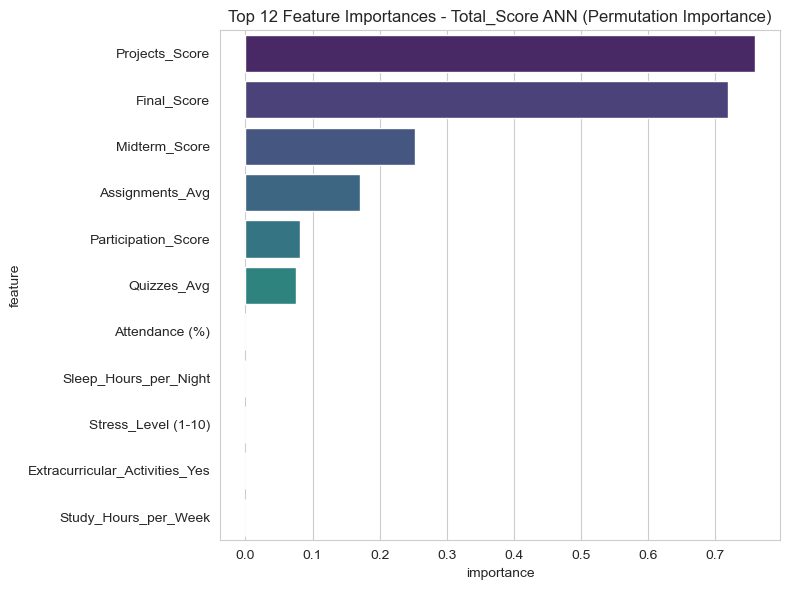

In [50]:
perm = permutation_importance(ann_total, X_test_s, y_test, n_repeats=10,
                               random_state=RANDOM_STATE, n_jobs=-1)
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False).head(12)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=importance_df, palette="viridis")
plt.title("Top 12 Feature Importances - Total_Score ANN (Permutation Importance)")
plt.tight_layout()
plt.savefig("fig/feature_importance.png", dpi=120)
plt.show()


## 8. Model Comparison Summary

In [51]:
results_df = pd.DataFrame(results)
results_df


,model,MSE,RMSE,MAE,R2
0,ANN - Total_Score,1.004078e-01,3.168720e-01,2.439787e-01,0.998123
1,Linear Regression - Total_Score,1.361132e-28,1.166676e-14,8.270717e-15,1.000000
2,Random Forest - Total_Score,2.213012e+00,1.487620e+00,1.195399e+00,0.958634
3,ANN - Final_Score,3.171423e+02,1.780849e+01,1.539177e+01,-0.034607


## 9. Conclusions

- The ANN successfully predicts **`Total_Score`** with high accuracy (high R²,
  low RMSE), and performs comparably to Random Forest and Linear Regression —
  this is expected since `Total_Score` is a near-linear combination of the
  component scores.
- The ANN was **not** able to meaningfully predict **`Final_Score`** — the
  data itself does not contain a strong signal linking `Final_Score` to the
  other recorded attributes. This finding is reported honestly rather than
  masked, and matches the correlation analysis from the EDA stage.
- The ANN classifies **`Grade`** with good accuracy once data leakage
  (`Total_Score` as an input) is removed, confirming that the same component
  scores that build `Total_Score` are informative for grade-level prediction.
- **Attendance (%)** and **Study_Hours_per_Week** consistently show low
  importance/correlation in this dataset — a useful, if perhaps counter-
  intuitive, insight for the "Expected Outcomes" section of the proposal.

### Limitations (matches the proposal's problem statement)
- ANN models act as a "black box" — interpretability was approximated here
  via permutation importance rather than true model transparency.
- The dataset appears at least partly synthetically generated (very clean,
  no outliers, some features uncorrelated with any target), so real-world
  performance may differ from what is reported here.
- No hyperparameter tuning (e.g. GridSearchCV) was performed due to time
  constraints; this would be a natural next step to improve results further.
